Loading data from Excel file...
Loaded DE        : 18812 timepoints,  15 systems
Loaded CD        : 18812 timepoints,  15 systems
Loaded BC        : 18812 timepoints,  15 systems
Loaded AB        : 18812 timepoints,  15 systems
Loaded AE        : 18812 timepoints,  15 systems
Total systems found: 15
Interfaces found: ['DE', 'CD', 'BC', 'AB', 'AE']

CALCULATING TIME TO FIRST LOSS (Threshold: Q < 0.6)

Processing DE interface...
  Completed: 9/15 systems lost contacts (60.0%)

Processing CD interface...
  Completed: 10/15 systems lost contacts (66.7%)

Processing BC interface...
  Completed: 6/15 systems lost contacts (40.0%)

Processing AB interface...
  Completed: 15/15 systems lost contacts (100.0%)

Processing AE interface...
  Completed: 14/15 systems lost contacts (93.3%)


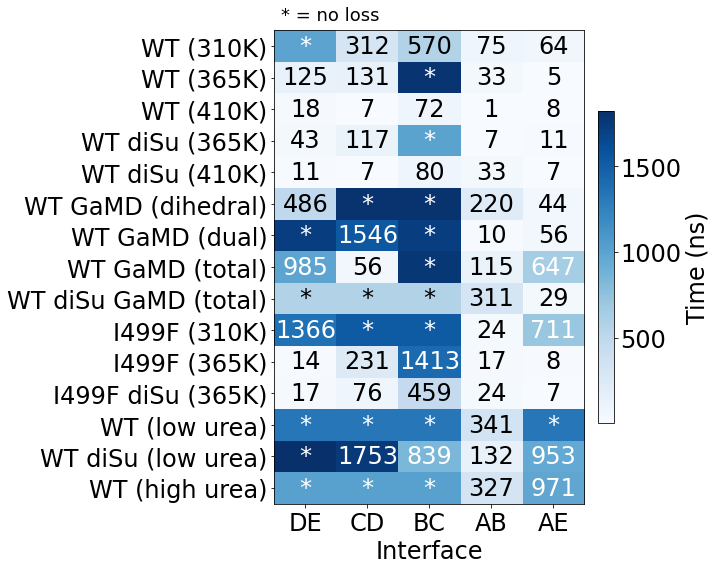

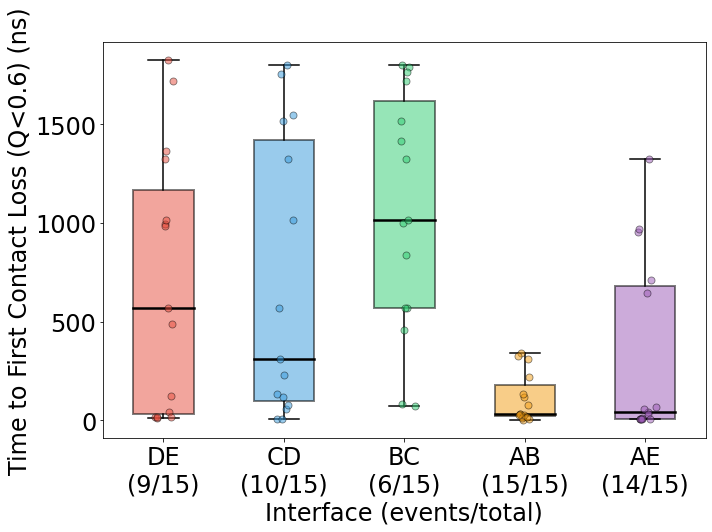

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_excel_data(filename):
    """
    Load fraction of native contacts from Excel file
    Each sheet represents an interface (AB, AE, BC, CD, DE)
    Each sheet has columns: ns, system1, system2, ..., systemN
    """
    excel_file = pd.ExcelFile(filename)
    data_dict = {}
    
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(filename, sheet_name=sheet_name)
        interface_name = sheet_name.upper().strip()
        data_dict[interface_name] = df
    
    first_sheet = data_dict[list(data_dict.keys())[0]]
    all_systems = [col for col in first_sheet.columns if col.lower() != 'ns']
    print(f"Total systems found: {len(all_systems)}")
    print(f"Interfaces found: {list(data_dict.keys())}")
    
    return data_dict, all_systems

def calculate_first_loss_time(time, Q, threshold=0.7):
    """Calculate time to first loss of native contacts below threshold"""
    # Find valid (non-NaN) data points
    valid_idx = ~np.isnan(Q)
    
    if not np.any(valid_idx):
        return np.nan, True, None, np.nan
    
    time_valid = time[valid_idx]
    Q_valid = Q[valid_idx]
    last_observed_time = time_valid[-1]
    
    loss_indices = np.where(Q_valid < threshold)[0]
    
    if len(loss_indices) > 0:
        first_idx = loss_indices[0]
        return time_valid[first_idx], False, first_idx, last_observed_time
    else:
        return last_observed_time, True, None, last_observed_time

def analyze_all_systems_and_interfaces(data_dict, all_systems, threshold=0.7):
    """Calculate first loss time for every system at every interface"""
    results = {}
    
    for interface, df in data_dict.items():
        results[interface] = {}
        time = df['ns'].values
                
        for system in all_systems:
            if system in df.columns:
                Q = df[system].values
                first_loss_time, is_censored, loss_idx, last_obs_time = \
                    calculate_first_loss_time(time, Q, threshold)
                
                if not np.isnan(first_loss_time):
                    results[interface][system] = {
                        'first_loss_time': first_loss_time,
                        'is_censored': is_censored,
                        'loss_index': loss_idx,
                        'last_observed_time': last_obs_time,
                        'trajectory_ended_early': last_obs_time < time[-1]
                    }
        
        n_events = sum(1 for s in results[interface].values() if not s['is_censored'])
        n_total = len(results[interface])
        print(f"  Completed: {n_events}/{n_total} systems lost contacts ({100*n_events/n_total:.1f}%)")
    
    return results

def plot_first_loss_heatmap(results, all_systems, interfaces, threshold):
    """Create heatmap showing first loss time for each system-interface combination"""
    matrix = np.full((len(all_systems), len(interfaces)), np.nan)
    
    for i, system in enumerate(all_systems):
        for j, interface in enumerate(interfaces):
            if interface in results and system in results[interface]:
                matrix[i, j] = results[interface][system]['first_loss_time']
    
    fig, ax = plt.subplots(figsize=(max(10, len(interfaces)*1.5), max(8, len(all_systems)*0.35)))
    
    im = ax.imshow(matrix, aspect='auto', cmap='Blues', interpolation='nearest')
    
    ax.set_xticks(range(len(interfaces)))
    ax.set_xticklabels(interfaces, fontsize=24)
    ax.set_yticks(range(len(all_systems)))
    ax.set_yticklabels(all_systems, fontsize=24)
    
    ax.set_xlabel('Interface', fontsize=24)
    ax.set_ylabel('', fontsize=24)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (ns)', fontsize=24)
    cbar.ax.tick_params(labelsize=24)

    for i in range(len(all_systems)):
        for j in range(len(interfaces)):
            if not np.isnan(matrix[i, j]):
                interface = interfaces[j]
                system = all_systems[i]
                is_censored = results[interface][system]['is_censored']
                
                text_str = '*' if is_censored else f'{matrix[i, j]:.0f}'
                text_color = 'black' if matrix[i, j] < np.nanmean(matrix) else 'white'
                
                ax.text(j, i, text_str, ha="center", va="center", 
                       color=text_color, fontsize=24)
    
    ax.text(0.02, 1.05, '* = no loss', transform=ax.transAxes,
            fontsize=18, verticalalignment='top')
    
    plt.tight_layout()
    plt.grid(False)
    plt.savefig('first_loss_heatmap_all.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_boxplot_comparison(results, interfaces, threshold):
    """Create box plot comparing first loss times across interfaces"""
    fig, ax = plt.subplots(figsize=(max(10, len(interfaces)*2), 7))
    
    data_for_plot = []
    labels = []
    colors_map = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', 
                  '#E67E22', '#1ABC9C', '#34495E']
    
    for interface in interfaces:
        if interface in results:
            first_loss_times = [res['first_loss_time'] for res in results[interface].values()]
            data_for_plot.append(first_loss_times)
            
            n_events = sum(1 for res in results[interface].values() if not res['is_censored'])
            n_total = len(results[interface])
            labels.append(f"{interface}\n({n_events}/{n_total})")
    
    colors = colors_map[:len(data_for_plot)]
    
    bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,
                    boxprops=dict(alpha=0.5, linewidth=2),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    for i, (data, color) in enumerate(zip(data_for_plot, colors), 1):
        x = np.random.normal(i, 0.04, size=len(data))
        ax.scatter(x, data, alpha=0.5, s=50, color=color, 
                  edgecolors='black', linewidth=0.8, zorder=3)
    
    ax.set_ylabel(f'Time to First Contact Loss (Q<{threshold}) (ns)', fontsize=24)
    ax.set_xlabel('Interface (events/total)', fontsize=24)
    ax.tick_params(axis='both', which='major', labelsize=24)
    
    plt.tight_layout()
    plt.savefig('boxplot_comparison_all_interfaces.png', dpi=300, bbox_inches='tight')
    plt.show()
    
##### 
filename = 'fnc_interface.xlsx'
data_dict, all_systems = load_excel_data(filename)
threshold = 0.6
results = analyze_all_systems_and_interfaces(data_dict, all_systems, threshold)
interfaces = list(data_dict.keys())
    
plot_first_loss_heatmap(results, all_systems, interfaces, threshold)
plot_boxplot_comparison(results, interfaces, threshold)

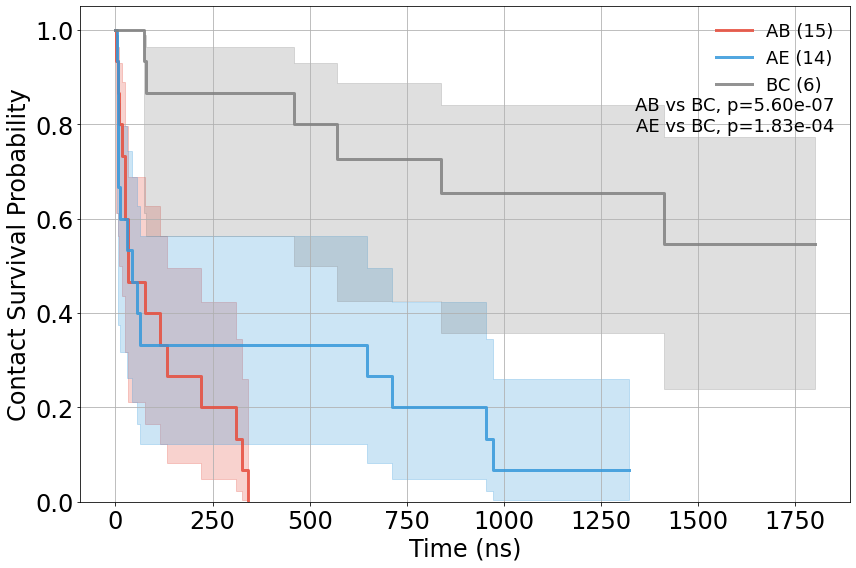

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy import stats

def prepare_survival_data_by_interface(results, interfaces):
    """Prepare survival data for Kaplan-Meier analysis"""
    survival_data = {}
    
    for interface in interfaces:
        if interface not in results or len(results[interface]) == 0:
            continue
        
        durations = []
        events = []
        systems = []
        ended_early = []
        
        for system, res in results[interface].items():
            durations.append(res['first_loss_time'])
            events.append(0 if res['is_censored'] else 1)
            systems.append(system)
            ended_early.append(res['trajectory_ended_early'])
        
        survival_data[interface] = {
            'durations': np.array(durations),
            'events': np.array(events),
            'systems': systems,
            'ended_early': np.array(ended_early)
        }
    
    return survival_data

survival_data = prepare_survival_data_by_interface(results, interfaces)

def fit_kaplan_meier_models(survival_data):
    """Fit Kaplan-Meier survival models for each interface"""
    kmf_models = {}
    
    for interface, data in survival_data.items():
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=data['durations'],
            event_observed=data['events'],
            label=interface
        )
        kmf_models[interface] = kmf
    
    return kmf_models

kmf_models = fit_kaplan_meier_models(survival_data)

def plot_test_vs_control(kmf_models, survival_data, test_interfaces=['AB', 'AE'], 
                        control='BC', threshold=0.6):
    """Plot focused comparison between test interfaces and control"""

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Define colors
    test_colors = {'AB': '#E74C3C', 'AE': '#3498DB'}
    control_color = 'grey'
    
    # Plot test interfaces
    for interface in test_interfaces:
        if interface in kmf_models:
            kmf = kmf_models[interface]
            data = survival_data[interface]
            n_events = np.sum(data['events'])
            
            kmf.plot_survival_function(
                ax=ax,
                ci_show=True,
                color=test_colors.get(interface, 'red'),
                linewidth=3,
                alpha=0.85,
                label=f'{interface} ({n_events})'
            )
    
    # Plot control
    kmf_control = kmf_models[control]
    data_control = survival_data[control]
    n_events_control = np.sum(data_control['events'])
    
    kmf_control.plot_survival_function(
        ax=ax,
        ci_show=True,
        color=control_color,
        linewidth=3,
        alpha=0.85,
        linestyle='-',
        label=f'{control} ({n_events_control})'
    )
    
    ax.set_xlabel('Time (ns)', fontsize=24)
    ax.set_ylabel('Contact Survival Probability', fontsize=24)
    ax.set_title(f'', fontsize=24, pad=20)
    ax.grid()
    ax.legend(fontsize=18, loc='best', frameon=False, edgecolor='black')
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.set_ylim([0, 1.05])

    if all(iface in survival_data for iface in test_interfaces) and control in survival_data:
        text_str = ""
        for test_iface in test_interfaces:
            if test_iface in survival_data:
                results = logrank_test(
                    survival_data[test_iface]['durations'],
                    survival_data[control]['durations'],
                    survival_data[test_iface]['events'],
                    survival_data[control]['events']
                )
                text_str += f"\n{test_iface} vs {control}, p={results.p_value:.2e}"
        
        ax.text(0.98, 0.74, text_str, transform=ax.transAxes,
                fontsize=18, verticalalignment='bottom', horizontalalignment='right')
    
    plt.tight_layout()
    plt.savefig('survival_curves_test_vs_control.png', dpi=300, bbox_inches='tight')
    plt.show()

if 'AB' in kmf_models and 'AE' in kmf_models and 'BC' in kmf_models:
    plot_test_vs_control(kmf_models, survival_data, 
                        test_interfaces=['AB', 'AE'], 
                        control='BC', 
                        threshold=threshold)